In [1]:
import uxarray as ux
import xarray as xr
import numpy as np
import geocat.datafiles as gdf
import geocat.comp as gc
import geocat.datafiles as gdf
import matplotlib.pyplot as plt

In [37]:
data_path = 'netcdf_files/e2p3b09.F2000climo.ne30pg3.ctl002.cam.h0.0005-01.zonal_mpsi_subset.nc'
grid_path = 'netcdf_files/ne30pg3_scrip_170604.nc'

uxds = ux.open_dataset(gdf.get(grid_path), gdf.get(data_path)).drop('lat')

#data_path = 'test/zonal_mpsi_hybrid.nc'
#grid_path = 'test/grid.nc'
#uxds = ux.open_dataset(grid_path, data_path)
#uxds

/var/folders/dd/_xm_pbpd3flgbvbnt7qhd70snnbpj_/T/ipykernel_27555/1039486070.py:4: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  uxds = ux.open_dataset(gdf.get(grid_path), gdf.get(data_path)).drop('lat')


In [38]:
# Subsetting

lon_bounds = (0,360)  # Full longitude
lat_bounds = (35, 45)

V_subset = uxds['V'].subset.bounding_box(
    lon_bounds,
    lat_bounds,
)
PS_subset = uxds['PS'].subset.bounding_box(
    lon_bounds,
    lat_bounds,
)

uxds = ux.UxDataset({
    'V': V_subset,
    'PS': PS_subset,
    'hyam': uxds['hyam'],
    'hybm': uxds['hybm']
}, uxgrid=V_subset.uxgrid)
uxds

<xarray.UxDataset> Size: 211kB
Dimensions:  (lev: 32, time: 1, n_face: 1593)
Coordinates:
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * time     (time) object 8B 0005-02-01 00:00:00
Dimensions without coordinates: n_face
Data variables:
    V        (time, lev, n_face) float32 204kB ...
    PS       (time, n_face) float32 6kB ...
    hyam     (lev) float64 256B ...
    hybm     (lev) float64 256B ...

In [39]:
print(f"V_subset NaN count: {V_subset.isnull().sum().values}")
print(f"PS_subset NaN count: {PS_subset.isnull().sum().values}")

V_subset NaN count: 0
PS_subset NaN count: 0


In [40]:
da_ipress = gc.interpolation.interp_hybrid_to_pressure(
    uxds.V, 
    uxds.PS, 
    uxds.hyam, 
    uxds.hybm)
ux_ipress = ux.UxDataArray(da_ipress, uxgrid=uxds.uxgrid)
ux_ipress


/Users/jkent/Documents/GeoCAT/geocat-comp/geocat/comp/interpolation.py:721: UserWarning: Interpolation point out of data bounds encountered
  output = func_interpolate(


<xarray.UxDataArray 'V' (time: 1, plev: 21, n_face: 1593)> Size: 268kB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [-4.30382205, -4.12475673, -4.03641445, ..., -0.64867409,
         -0.97216295, -1.33857767],
        [-4.80853142, -4.73281082, -4.71488799, ..., -0.6517731 ,
         -1.15500701, -1.54386502],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]], shape=(1, 21, 1593))
Coordinates:
  * time     (time) object 8B 0005-02-01 00:00:00
  * plev     (plev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
Dimensions without coordinates: n_face
Attributes:
    mdims:         1
    units:         m/s
    long_name:     Meridional wind
    cell_methods:  time: mean

In [54]:
lat_array = np.arange(lat_bounds[0]+1, lat_bounds[1], 1)
lat_array


array([36, 37, 38, 39, 40, 41, 42, 43, 44])

In [55]:
# zonal mean wind
ux_v_zonal = ux_ipress.zonal_mean(lat=lat_array)
ux_v_zonal['plev'] = ux_ipress.plev
ux_v_zonal


<xarray.DataArray 'V_zonal_mean' (time: 1, plev: 21, latitudes: 9)> Size: 2kB
array([[[            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan],
        [            nan,             nan,             nan,
                     nan,             nan, -6.80396284e-01,
         -8.20914127e-01, -9.74238265e-01, -1.10234122e+00],
        [-2.24328654e-01, -4.28201958e-01, -6.34235889e-01,
         -7.96003233e-01, -9.33470119e-01, -1.09077720e+00,
         -1.27186085e+00, -1.42117112e+00, -1.55864361e+00],
        [-4.36955071e-01, -5.96721643e-01, -7.80806423e-01,
         -9.46197627e-01, -1.09789308e+00, -1.25140521e+00,
         -1.44574006e+00, -1.62944834e+00, -1.82594978e+00],
        [-3.91668711e-01, -5.12456305e-01, -7.35659374e-01,
         -9.61055084e-01, -1.19555269e+00, -1.42954525e+00,
...
          2.65796345e+00,  2.89235672e+00,  3.13696294e+00,
          3.39277054e+00,  3.66104960e+00,  3.94517673e+00],
        [ 2.48561259e+00,  2.76486812e+00,  3.09839148e+00,
          3.45163022e+00,  3.82417519e+00,  4.21519168e+00,
          4.62637940e+00,  5.05601796e+00,  5.51075398e+00],
        [ 2.46660542e+00,  2.77310493e+00,  3.13481369e+00,
          3.52396982e+00,  3.94006069e+00,  4.38075259e+00,
          4.84903252e+00,  5.34192360e+00,  5.86693805e+00],
        [ 2.20228519e+00,  2.49806361e+00,  2.84596958e+00,
          3.23179665e+00,  3.65589566e+00,  4.11613043e+00,
          4.61534654e+00,  5.15062671e+00,  5.72820562e+00],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan]]])
Coordinates:
  * plev       (plev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
  * latitudes  (latitudes) int64 72B 36 37 38 39 40 41 42 43 44
Dimensions without coordinates: time
Attributes:
    zonal_mean:    True
    conservative:  False

In [56]:
ux_PS_zonal = uxds.PS.zonal_mean(lat=lat_array)
ux_PS_zonal

<xarray.DataArray 'PS_zonal_mean' (time: 1, latitudes: 9)> Size: 36B
array([[90413.44 , 91864.96 , 93126.59 , 94221.37 , 94957.22 , 95212.9  ,
        95159.23 , 95563.125, 96351.98 ]], dtype=float32)
Coordinates:
  * latitudes  (latitudes) int64 72B 36 37 38 39 40 41 42 43 44
Dimensions without coordinates: time
Attributes:
    zonal_mean:    True
    conservative:  False

In [49]:
# Constants
a = 6.371e6  # Earth radius (m)
g = 9.80665  # gravity (m/s^2)

lat = ux_v_zonal.latitudes
da_scaling_factor = 2 * np.pi * a * np.cos(lat) / g

In [50]:
np_dp_zonal = gc.meteorology.delta_pressure(ux_v_zonal.plev, ux_PS_zonal)

da_dp_zonal = xr.DataArray(
    np_dp_zonal,
    dims=["time", "latitudes", "plev"],
    coords={
        "plev": ux_v_zonal.plev,
        "latitudes": ux_v_zonal.latitudes
        },
    name="delta_pressure"
)
ux_dp_zonal = ux.UxDataArray(da_dp_zonal, uxgrid=uxds.uxgrid)

In [51]:
# Reverse plev, integrate, then reverse back
integrand = ux_v_zonal * ux_dp_zonal
ux_mpsi = (
    integrand.isel(plev=slice(None, None, -1))  # reverse plev: now top is first
    .cumsum(dim="plev")
)
ux_mpsi = ux_mpsi * da_scaling_factor

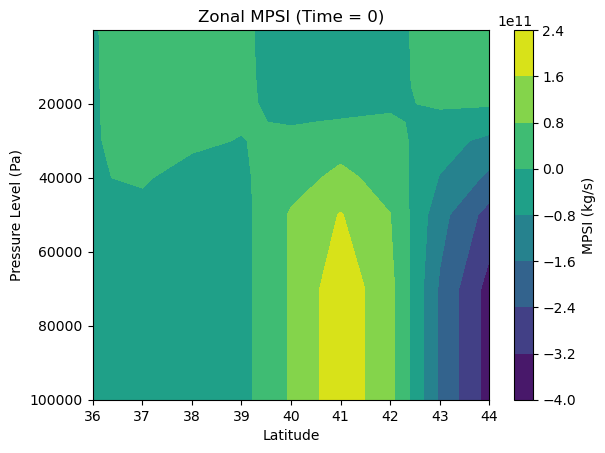

In [52]:
mpsi0 = ux_mpsi.isel(time=0)
plt.contourf(
    mpsi0['latitudes'],
    mpsi0['plev'],
    mpsi0
)
plt.xlabel("Latitude")
plt.ylabel("Pressure Level (Pa)")
plt.gca().invert_yaxis()
plt.colorbar(label="MPSI (kg/s)")
plt.title("Zonal MPSI (Time = 0)")
plt.show()